# Industry Research Project: EDA + Modeling Book

## Goal (plain language)
This notebook builds a practical and research-ready workflow on the UNSW-NB15 dataset.
It starts from basic EDA, moves into cyber model baselines, and then adds paper-style evaluation so results are report-ready.

## Numbered Section Index (where each part starts)
1. **Phase 1 - Basic EDA**: data load, head/tail, shape, NaN checks, starter visualizations
2. **Phase 2 - Industry-Style EDA**: feature audit, class profile, correlations, outliers, drift (PSI), shortlist
3. **Phase 3 - Cyber Algorithms**: Logistic Regression, Random Forest, Isolation Forest
4. **Phase 4 - Paper-Style Evaluation**: advanced metrics, confusion diagnostics, threshold tuning, ablation, multiclass check
5. **Professor Discussion Block**: what/why/how questions for final direction confirmation

## Scope in this notebook
1. Build a clean and reproducible EDA flow
2. Create practical baseline models for IDS
3. Add publication-style evaluation outputs
4. Produce discussion-ready tables for your professor meeting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

train_path = 'UNSW_NB15_training-set.csv'
test_path = 'UNSW_NB15_testing-set.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Keep source split so analysis can compare train vs test later.
df = pd.concat([
    df_train.assign(_split='train'),
    df_test.assign(_split='test')
], ignore_index=True)

print('Train shape:', df_train.shape)
print('Test shape :', df_test.shape)
print('Combined shape:', df.shape)

Train shape: (82332, 45)
Test shape : (175341, 45)
Combined shape: (257673, 46)


In [2]:
# Required basic EDA checks
print('Rows x Columns (shape):', df.shape)
print('\nNumber of columns:', df.shape[1])

print('\n--- HEAD (top 5 rows) ---')
display(df.head())

print('--- TAIL (last 5 rows) ---')
display(df.tail())

Rows x Columns (shape): (257673, 46)

Number of columns: 46

--- HEAD (top 5 rows) ---


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label,_split
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,2,0,0,0,1,2,0,Normal,0,train
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,2,0,0,0,1,2,0,Normal,0,train
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,3,0,0,0,1,3,0,Normal,0,train
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,3,0,0,0,2,3,0,Normal,0,train
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,3,0,0,0,2,3,0,Normal,0,train


--- TAIL (last 5 rows) ---


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label,_split
257668,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,24,0,0,0,24,24,0,Generic,1,test
257669,175338,0.505762,tcp,-,FIN,10,8,620,354,33.612649,...,2,0,0,0,1,1,0,Shellcode,1,test
257670,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,13,0,0,0,3,12,0,Generic,1,test
257671,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,30,0,0,0,30,30,0,Generic,1,test
257672,175341,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,30,0,0,0,30,30,0,Generic,1,test


In [3]:
# Find NaN values
nan_count = df.isna().sum().sort_values(ascending=False)
nan_pct = (df.isna().mean() * 100).sort_values(ascending=False)

nan_summary = pd.DataFrame({
    'NaN_Count': nan_count,
    'NaN_Percent': nan_pct.round(2)
})

print('Total NaN values in dataset:', int(df.isna().sum().sum()))
display(nan_summary[nan_summary['NaN_Count'] > 0])

if (nan_summary['NaN_Count'] > 0).sum() == 0:
    print('No NaN values found in any column.')

Total NaN values in dataset: 0


,NaN_Count,NaN_Percent


No NaN values found in any column.


No missing-value plot shown because dataset has no NaNs.


C:\Users\heet5\AppData\Local\Temp\ipykernel_9236\488224036.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


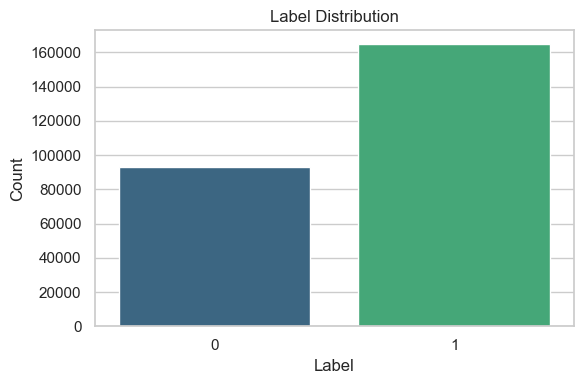

C:\Users\heet5\AppData\Local\Temp\ipykernel_9236\488224036.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_attack.values, y=top_attack.index, palette='magma')


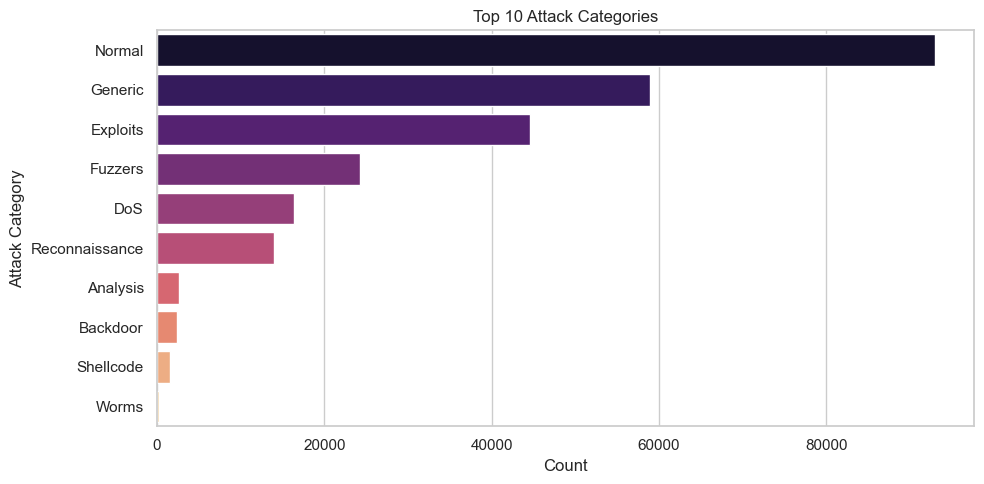

In [4]:
# Usable starter visualizations for cybersecurity EDA

# 1) Missing values (top columns, if any)
nan_nonzero = nan_summary[nan_summary['NaN_Count'] > 0].head(20)

if len(nan_nonzero) > 0:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=nan_nonzero['NaN_Count'].values, y=nan_nonzero.index, palette='Reds_r')
    plt.title('Top Columns by Missing Values')
    plt.xlabel('NaN Count')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print('No missing-value plot shown because dataset has no NaNs.')

# 2) Label distribution (normal vs attack)
if 'label' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='label', palette='viridis')
    plt.title('Label Distribution')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# 3) Top attack categories (if available)
if 'attack_cat' in df.columns:
    top_attack = df['attack_cat'].fillna('Unknown').value_counts().head(10)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_attack.values, y=top_attack.index, palette='magma')
    plt.title('Top 10 Attack Categories')
    plt.xlabel('Count')
    plt.ylabel('Attack Category')
    plt.tight_layout()
    plt.show()

## Notes for next phase
For integration with advanced cyber defense algorithms and future super-computing workflows, next EDA steps usually include:
- data types and casting audit
- cardinality checks for categorical features
- outlier and distribution analysis for numeric features
- feature correlation / redundancy checks
- train-test drift checks

## Phase 2: Industry-Style EDA for Cybersecurity Modeling

This section extends basic EDA to support:
- feature blending with cybersecurity algorithms (including Rover/Shrover-like approaches)
- scalable execution in future high-performance / super-computing pipelines

Focus areas:
1. Data type and feature audit
2. Class balance and attack-profile analysis
3. Numeric behavior (distribution, outliers)
4. Correlation and redundancy analysis
5. Train-test drift indicators
6. Practical feature shortlist for model blending

In [5]:
# Data type and feature audit

from IPython.display import display

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

schema_df = pd.DataFrame({
    'feature': df.columns,
    'dtype': [str(df[c].dtype) for c in df.columns],
    'missing_count': [int(df[c].isna().sum()) for c in df.columns],
    'missing_pct': [round(float(df[c].isna().mean() * 100), 4) for c in df.columns],
    'n_unique': [int(df[c].nunique(dropna=True)) for c in df.columns]
}).sort_values(['dtype', 'feature']).reset_index(drop=True)

print('Total features:', df.shape[1])
print('Numeric features:', len(num_cols))
print('Categorical features:', len(cat_cols))

display(schema_df.head(20))

print('\nCategorical columns:', cat_cols)

Total features: 46
Numeric features: 41
Categorical features: 5


,feature,dtype,missing_count,missing_pct,n_unique
0,ackdat,float64,0,0.0,53248
1,dinpkt,float64,0,0.0,110270
2,djit,float64,0,0.0,114861
3,dload,float64,0,0.0,116380
4,dur,float64,0,0.0,109945
5,rate,float64,0,0.0,115763
6,sinpkt,float64,0,0.0,114318
7,sjit,float64,0,0.0,117101
8,sload,float64,0,0.0,121356
9,synack,float64,0,0.0,57366



Categorical columns: ['proto', 'service', 'state', 'attack_cat', '_split']


In [6]:
# Summary statistics and categorical cardinality

display(df[num_cols].describe().T.head(20))

cat_cardinality = pd.DataFrame({
    'feature': cat_cols,
    'unique_values': [df[c].nunique(dropna=True) for c in cat_cols],
    'top_value': [df[c].mode(dropna=True)[0] if df[c].nunique(dropna=True) > 0 else np.nan for c in cat_cols],
    'top_value_freq': [int(df[c].value_counts(dropna=True).iloc[0]) if df[c].nunique(dropna=True) > 0 else 0 for c in cat_cols]
}).sort_values('unique_values', ascending=False).reset_index(drop=True)

print('Categorical cardinality (high to low):')
display(cat_cardinality)

,count,mean,std,min,25%,50%,75%,max
id,257673.0,7.281182e+04,4.892992e+04,1.0,32210.000000,64419.000000,1.109230e+05,1.753410e+05
dur,257673.0,1.246715e+00,5.974305e+00,0.0,0.000008,0.004285,6.857770e-01,5.999999e+01
spkts,257673.0,1.977714e+01,1.359472e+02,1.0,2.000000,4.000000,1.200000e+01,1.064600e+04
dpkts,257673.0,1.851470e+01,1.119860e+02,0.0,0.000000,2.000000,1.000000e+01,1.101800e+04
sbytes,257673.0,8.572952e+03,1.737739e+05,24.0,114.000000,528.000000,1.362000e+03,1.435577e+07
dbytes,257673.0,1.438729e+04,1.461993e+05,0.0,0.000000,178.000000,1.064000e+03,1.465753e+07
rate,257673.0,9.125391e+04,1.603446e+05,0.0,30.789277,2955.664893,1.250000e+05,1.000000e+06
sttl,257673.0,1.800009e+02,1.024883e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,257673.0,8.475496e+01,1.127621e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,257673.0,7.060869e+07,1.857313e+08,0.0,12318.004880,743942.312500,8.000000e+07,5.988000e+09


Categorical cardinality (high to low):


,feature,unique_values,top_value,top_value_freq
0,proto,133,tcp,123041
1,service,13,-,141321
2,state,11,FIN,117164
3,attack_cat,10,Normal,93000
4,_split,2,test,175341


Label distribution (%)


label
1    63.91
0    36.09
Name: percent, dtype: float64

Label distribution by split (%)


label,0,1
_split,,
test,31.94,68.06
train,44.94,55.06


Top attack categories (%)


attack_cat
Normal            36.09
Generic           22.85
Exploits          17.28
Fuzzers            9.41
DoS                6.35
Reconnaissance     5.43
Analysis           1.04
Backdoor           0.90
Shellcode          0.59
Worms              0.07
Name: proportion, dtype: float64

C:\Users\heet5\AppData\Local\Temp\ipykernel_9236\4057096910.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


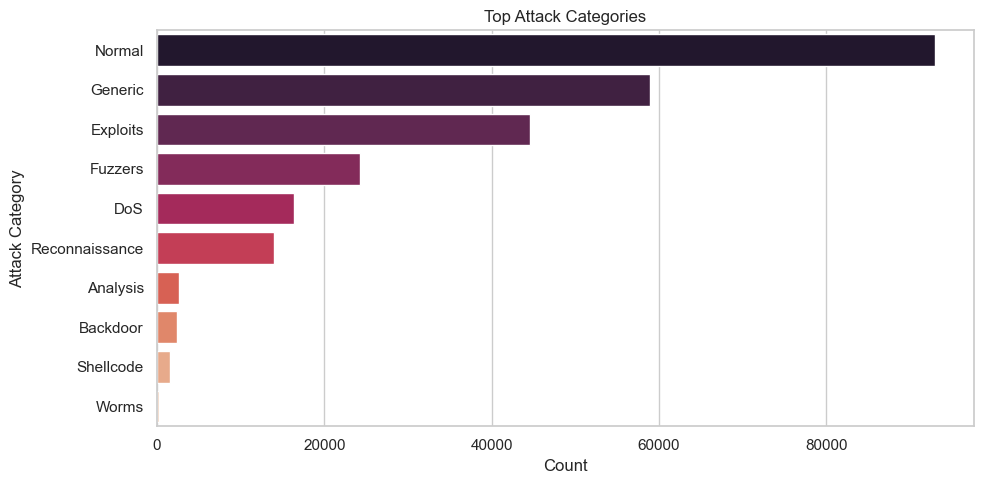

In [7]:
# Class balance and attack profile checks

if 'label' in df.columns:
    label_dist = (df['label'].value_counts(normalize=True) * 100).rename('percent').round(2)
    print('Label distribution (%)')
    display(label_dist)

    if '_split' in df.columns:
        split_label = pd.crosstab(df['_split'], df['label'], normalize='index') * 100
        print('Label distribution by split (%)')
        display(split_label.round(2))

if 'attack_cat' in df.columns:
    attack_dist = (df['attack_cat'].fillna('Unknown').value_counts(normalize=True) * 100).head(15)
    print('Top attack categories (%)')
    display(attack_dist.round(2))

    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df,
        y=df['attack_cat'].fillna('Unknown'),
        order=df['attack_cat'].fillna('Unknown').value_counts().head(12).index,
        palette='rocket'
    )
    plt.title('Top Attack Categories')
    plt.xlabel('Count')
    plt.ylabel('Attack Category')
    plt.tight_layout()
    plt.show()

Top numeric features by |correlation| with label:


,abs_corr_with_label
label,1.000000
sttl,0.624082
ct_state_ttl,0.476559
ct_dst_sport_ltm,0.371672
swin,0.364877
dload,0.352169
dwin,0.339166
rate,0.335883
ct_src_dport_ltm,0.318518
ct_dst_src_ltm,0.299609


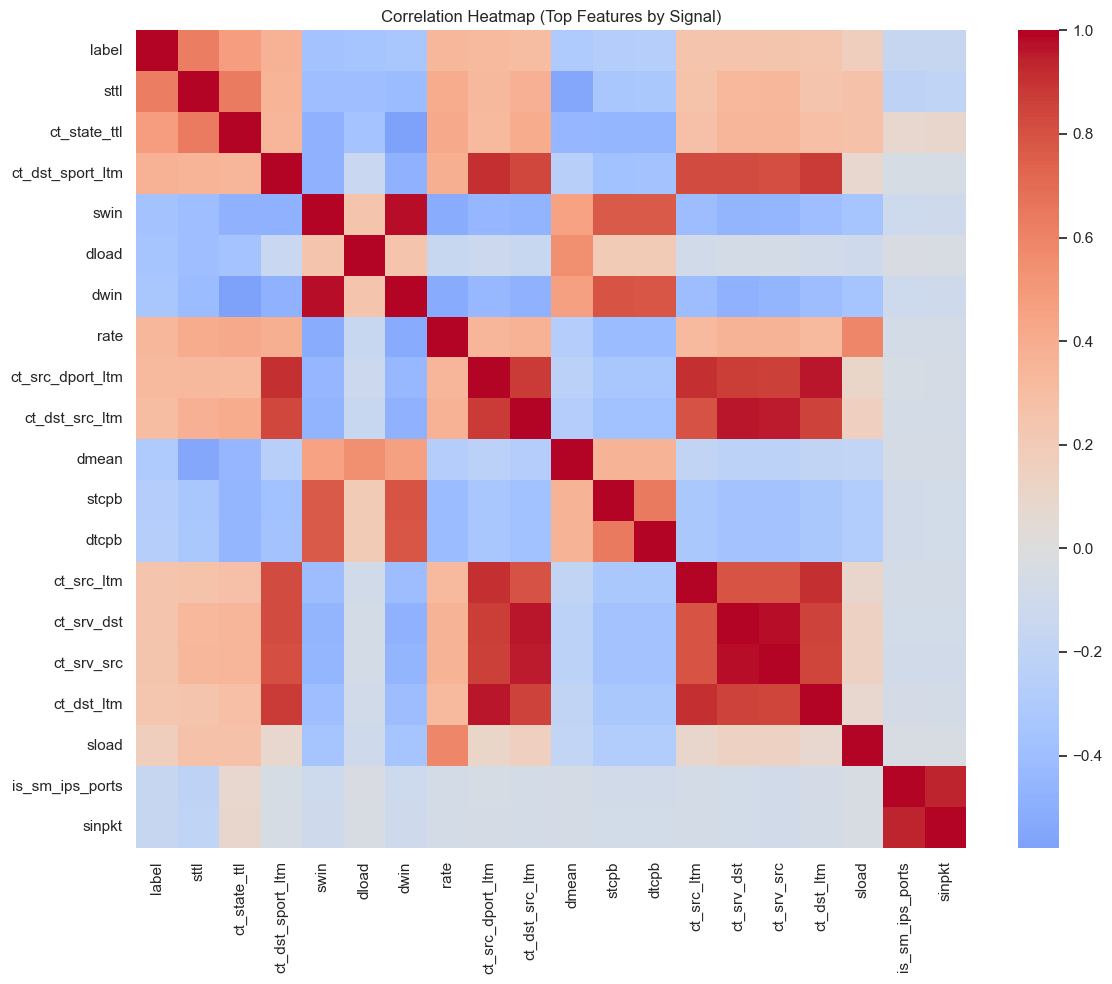

Highly redundant feature pairs (|corr| >= 0.95):


,feature_1,feature_2,abs_corr
0,is_ftp_login,ct_ftp_cmd,0.998855
1,dbytes,dloss,0.996711
2,sbytes,sloss,0.995772
3,swin,dwin,0.980458
4,dpkts,dloss,0.979612
5,ct_srv_src,ct_srv_dst,0.979467
6,dpkts,dbytes,0.973445
7,spkts,sloss,0.971859
8,spkts,sbytes,0.964393
9,ct_dst_ltm,ct_src_dport_ltm,0.961518


In [8]:
# Correlation with target (label) and redundancy checks

if 'label' in df.columns:
    numeric_for_model = [c for c in num_cols if c not in ['id']]
    corr_to_label = df[numeric_for_model].corrwith(df['label']).abs().sort_values(ascending=False)

    print('Top numeric features by |correlation| with label:')
    display(corr_to_label.head(20).to_frame('abs_corr_with_label'))

    top_corr_features = corr_to_label.head(20).index.tolist()
    corr_mat = df[top_corr_features].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_mat, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap (Top Features by Signal)')
    plt.tight_layout()
    plt.show()

    # High-correlation pairs indicate potential redundancy.
    corr_abs = df[numeric_for_model].corr().abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

    redundant_pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_corr'})
        .query('abs_corr >= 0.95')
        .sort_values('abs_corr', ascending=False)
        .reset_index(drop=True)
    )

    print('Highly redundant feature pairs (|corr| >= 0.95):')
    if len(redundant_pairs) == 0:
        print('No highly redundant numeric pairs at threshold 0.95')
    else:
        display(redundant_pairs.head(30))

Top numeric features by outlier % (IQR method):


,feature,outlier_pct_iqr,std,n_unique
0,dload,22.336838,2.412372e+06,116380
1,ct_src_dport_ltm,19.021783,8.160822e+00,52
2,ct_dst_sport_ltm,18.722955,5.831515e+00,35
3,ct_dst_src_ltm,16.850427,1.112075e+01,58
4,ct_dst_ltm,16.450307,8.173749e+00,52
5,dbytes,15.532865,1.461993e+05,8653
6,dloss,15.391601,5.370222e+01,476
7,spkts,13.533044,1.359472e+02,646
8,ct_srv_dst,13.213647,1.087475e+01,57
9,dmean,12.880278,2.540410e+02,1362


C:\Users\heet5\AppData\Local\Temp\ipykernel_9236\1213160676.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


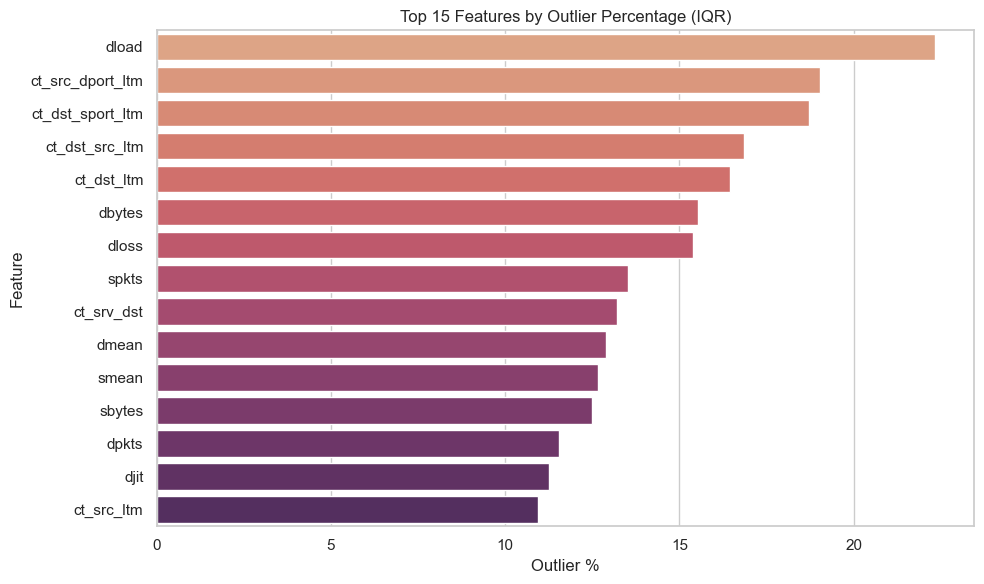

In [9]:
# Outlier pressure (IQR rule) for numeric features

def iqr_outlier_ratio(series: pd.Series) -> float:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return float(((series < low) | (series > high)).mean() * 100)

outlier_summary = pd.DataFrame({
    'feature': num_cols,
    'outlier_pct_iqr': [iqr_outlier_ratio(df[c]) for c in num_cols],
    'std': [float(df[c].std()) for c in num_cols],
    'n_unique': [int(df[c].nunique()) for c in num_cols]
}).sort_values('outlier_pct_iqr', ascending=False).reset_index(drop=True)

print('Top numeric features by outlier % (IQR method):')
display(outlier_summary.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=outlier_summary.head(15),
    x='outlier_pct_iqr',
    y='feature',
    palette='flare'
)
plt.title('Top 15 Features by Outlier Percentage (IQR)')
plt.xlabel('Outlier %')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Top features by train-test drift (PSI):


,feature,psi_train_vs_test
0,id,1.197899
1,sinpkt,0.129948
2,ct_src_dport_ltm,0.113144
3,ct_dst_src_ltm,0.097379
4,dur,0.084035
5,ct_dst_ltm,0.081261
6,ct_dst_sport_ltm,0.076897
7,ct_srv_src,0.051845
8,ct_srv_dst,0.047378
9,ct_src_ltm,0.045404


C:\Users\heet5\AppData\Local\Temp\ipykernel_9236\4019445869.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=drift_df.head(15), x='psi_train_vs_test', y='feature', palette='crest')


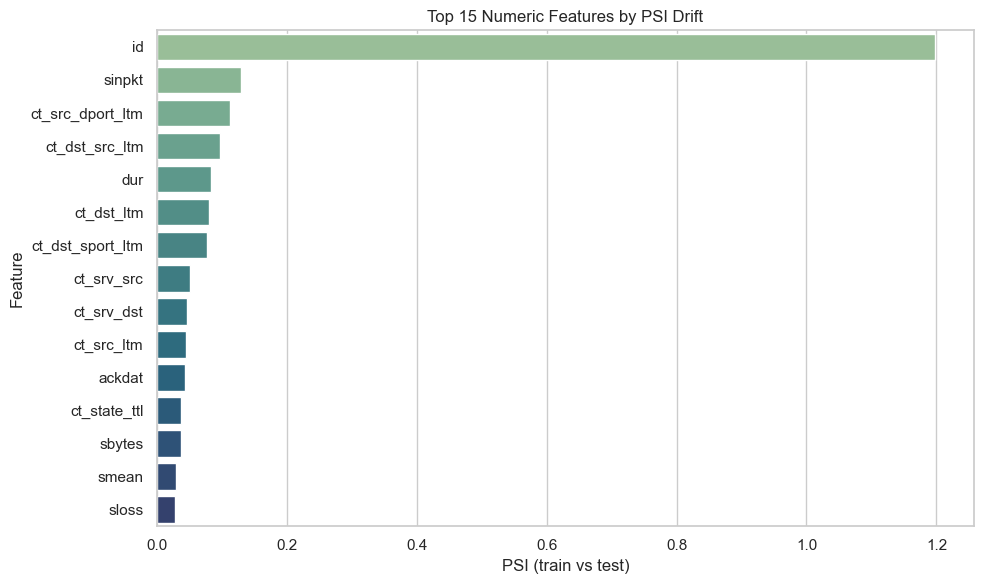

In [10]:
# Train-test drift check using PSI (Population Stability Index)

# PSI near 0 means stable; higher values suggest drift.
def psi_for_feature(train_s: pd.Series, test_s: pd.Series, bins: int = 10) -> float:
    train_s = train_s.replace([np.inf, -np.inf], np.nan).dropna()
    test_s = test_s.replace([np.inf, -np.inf], np.nan).dropna()

    if train_s.nunique() < 2 or test_s.nunique() < 2:
        return 0.0

    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(train_s.quantile(quantiles).values)

    if len(cut_points) < 3:
        return 0.0

    # Extend edge bins to include all values.
    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_bins = pd.cut(train_s, bins=cut_points, include_lowest=True)
    test_bins = pd.cut(test_s, bins=cut_points, include_lowest=True)

    train_dist = train_bins.value_counts(normalize=True, sort=False)
    test_dist = test_bins.value_counts(normalize=True, sort=False)

    eps = 1e-6
    train_dist = train_dist + eps
    test_dist = test_dist + eps

    psi = ((train_dist - test_dist) * np.log(train_dist / test_dist)).sum()
    return float(psi)

if '_split' in df.columns:
    df_train_only = df[df['_split'] == 'train']
    df_test_only = df[df['_split'] == 'test']

    drift_rows = []
    for c in num_cols:
        if c in ['label']:
            continue
        drift_rows.append({
            'feature': c,
            'psi_train_vs_test': psi_for_feature(df_train_only[c], df_test_only[c], bins=10)
        })

    drift_df = pd.DataFrame(drift_rows).sort_values('psi_train_vs_test', ascending=False).reset_index(drop=True)
    print('Top features by train-test drift (PSI):')
    display(drift_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=drift_df.head(15), x='psi_train_vs_test', y='feature', palette='crest')
    plt.title('Top 15 Numeric Features by PSI Drift')
    plt.xlabel('PSI (train vs test)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

In [11]:
# Practical feature shortlist for model blending

# Rules of thumb:
# - good predictive signal to label
# - low missingness
# - manageable drift
# - avoid extremely high redundancy in final model design

if 'label' in df.columns and '_split' in df.columns:
    base = pd.DataFrame({'feature': [c for c in num_cols if c not in ['label', 'id']]})

    signal = (
        df[base['feature'].tolist()]
        .corrwith(df['label'])
        .abs()
        .rename('abs_corr_label')
        .reset_index()
        .rename(columns={'index': 'feature'})
    )

    missing = pd.DataFrame({
        'feature': base['feature'],
        'missing_pct': [float(df[c].isna().mean() * 100) for c in base['feature']]
    })

    unique_df = pd.DataFrame({
        'feature': base['feature'],
        'n_unique': [int(df[c].nunique()) for c in base['feature']]
    })

    blend_ready = (
        base
        .merge(signal, on='feature', how='left')
        .merge(missing, on='feature', how='left')
        .merge(unique_df, on='feature', how='left')
        .merge(drift_df, on='feature', how='left')
        .fillna({'psi_train_vs_test': 0.0})
        .sort_values(['abs_corr_label', 'psi_train_vs_test'], ascending=[False, True])
        .reset_index(drop=True)
    )

    recommended = blend_ready.query('missing_pct <= 1 and psi_train_vs_test <= 0.25').head(20)

    print('Top blend-ready numeric features (initial shortlist):')
    display(recommended)

    # Optional export for downstream model pipelines.
    recommended.to_csv('feature_shortlist_blend_ready.csv', index=False)
    print('Saved shortlist to: feature_shortlist_blend_ready.csv')

Top blend-ready numeric features (initial shortlist):


,feature,abs_corr_label,missing_pct,n_unique,psi_train_vs_test
0,sttl,0.624082,0.0,13,0.009247
1,ct_state_ttl,0.476559,0.0,7,0.037310
2,ct_dst_sport_ltm,0.371672,0.0,35,0.076897
3,swin,0.364877,0.0,22,0.000000
4,dload,0.352169,0.0,116380,0.009732
5,dwin,0.339166,0.0,19,0.000000
6,rate,0.335883,0.0,115763,0.016603
7,ct_src_dport_ltm,0.318518,0.0,52,0.113144
8,ct_dst_src_ltm,0.299609,0.0,58,0.097379
9,dmean,0.295173,0.0,1362,0.010419


Saved shortlist to: feature_shortlist_blend_ready.csv


## Interpretation Guide (for project report)

- **Signal strength**: higher `abs_corr_label` means a feature is likely useful for attack classification.
- **Drift stability (PSI)**:
  - `< 0.10` usually stable
  - `0.10 - 0.25` moderate shift
  - `> 0.25` significant shift (handle with caution)
- **Outlier-heavy features** may need robust scaling, clipping, or transformation.
- **Highly redundant pairs** (`|corr| >= 0.95`) suggest dimensionality reduction or regularization.

For future super-computing integration, keep this workflow modular:
- feature profiling stage
- drift monitoring stage
- shortlist export stage

This allows distributed execution and easy algorithm blending in larger cyber defense pipelines.

## Phase 3: Cyber Algorithms (Practical Starter)

Now we move from *understanding* the data to *using* it in security algorithms.

In simple words, this phase answers:
- Can we detect attacks with supervised learning?
- Can we detect unusual traffic even without labels (anomaly detection)?
- Which approach looks stable enough for future scaling?

We will start with three practical algorithms:
1. **Logistic Regression** (fast baseline)
2. **Random Forest** (non-linear decision patterns)
3. **Isolation Forest** (unsupervised anomaly detection)

> Human note: we keep this first pass practical and reproducible, then optimize later for distributed/super-computing environments.

In [12]:
# Phase 3 setup: clean train/test split for modeling

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

# We use original train/test files to avoid leakage and keep evaluation honest.
train_df = df_train.copy()
test_df = df_test.copy()

# Target (0 = normal, 1 = attack)
y_train = train_df['label'].astype(int)
y_test = test_df['label'].astype(int)

# Features for supervised models
X_train = train_df.drop(columns=['label'], errors='ignore')
X_test = test_df.drop(columns=['label'], errors='ignore')

# `attack_cat` carries very direct attack information; remove for fair binary detection modeling.
X_train = X_train.drop(columns=['attack_cat'], errors='ignore')
X_test = X_test.drop(columns=['attack_cat'], errors='ignore')

cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

print('Supervised model feature count:', X_train.shape[1])
print('Numeric features:', len(num_features))
print('Categorical features:', len(cat_features))

Supervised model feature count: 43
Numeric features: 40
Categorical features: 3


In [13]:
# Train and evaluate supervised cyber algorithms

def evaluate_binary_model(name, model, X_te, y_te):
    """Small helper so results stay readable and comparable."""
    pred = model.predict(X_te)

    # For ROC-AUC, we try probabilities first, then decision scores.
    if hasattr(model, 'predict_proba'):
        score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        score = model.decision_function(X_te)
    else:
        score = pred

    return {
        'model': name,
        'accuracy': accuracy_score(y_te, pred),
        'precision': precision_score(y_te, pred, zero_division=0),
        'recall': recall_score(y_te, pred, zero_division=0),
        'f1': f1_score(y_te, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_te, score)
    }

# Shared preprocessing for mixed data (numeric + categorical).
# Keeping this explicit makes it easier to port to larger pipelines later.
preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ]
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=500, solver='lbfgs'),
    # Balanced class weights help when attack vs normal is not perfectly balanced.
    'RandomForest': RandomForestClassifier(
        n_estimators=160,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        # n_jobs=1 keeps it stable in restricted/sandboxed environments.
        n_jobs=1,
        class_weight='balanced_subsample'
    )
}

results = []
trained = {}

for name, algo in models.items():
    print(f'\nTraining {name} ...')
    pipe = Pipeline(steps=[('prep', preprocess), ('model', algo)])
    pipe.fit(X_train, y_train)

    metrics_row = evaluate_binary_model(name, pipe, X_test, y_test)
    results.append(metrics_row)
    trained[name] = pipe

results_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
print('\nSupervised model benchmark (test set):')
display(results_df)


Training LogisticRegression ...

Training RandomForest ...

Supervised model benchmark (test set):


,model,accuracy,precision,recall,f1,roc_auc
0,RandomForest,0.724411,0.967815,0.615564,0.752507,0.911119
1,LogisticRegression,0.465801,0.856267,0.258528,0.397148,0.808235


In [14]:
# Unsupervised cyber algorithm: Isolation Forest

# Human logic: train anomaly detector mostly on normal traffic,
# then see if attack traffic appears as anomalies.
unsup_train = train_df[train_df['label'] == 0].copy()
unsup_test = test_df.copy()

y_unsup_test = unsup_test['label'].astype(int)

X_unsup_train = unsup_train.drop(columns=['label', 'attack_cat'], errors='ignore').copy()
X_unsup_test = unsup_test.drop(columns=['label', 'attack_cat'], errors='ignore').copy()

# Quick numeric-only encoding for anomaly model stability.
# We encode every non-numeric column (including pandas 'string' dtypes),
# so Isolation Forest receives a fully numeric matrix.
non_numeric_cols = X_unsup_train.select_dtypes(exclude=[np.number]).columns.tolist()

for col in non_numeric_cols:
    # We combine train+test category mapping so codes align.
    all_vals = pd.concat([X_unsup_train[col], X_unsup_test[col]], axis=0).fillna('missing').astype(str)
    cat = pd.Categorical(all_vals)
    X_unsup_train[col] = pd.Categorical(X_unsup_train[col].fillna('missing').astype(str), categories=cat.categories).codes
    X_unsup_test[col] = pd.Categorical(X_unsup_test[col].fillna('missing').astype(str), categories=cat.categories).codes

iso = IsolationForest(
    n_estimators=220,
    contamination='auto',
    random_state=42,
    # Same reason as above: favor reliability over parallelism here.
    n_jobs=1
)

print('Training Isolation Forest on normal traffic only ...')
iso.fit(X_unsup_train)

iso_pred = iso.predict(X_unsup_test)
# IsolationForest: -1 means anomaly, +1 means inlier.
iso_attack_pred = np.where(iso_pred == -1, 1, 0)
iso_scores = -iso.score_samples(X_unsup_test)  # higher => more anomalous

iso_metrics = {
    'model': 'IsolationForest(normal-only train)',
    'accuracy': accuracy_score(y_unsup_test, iso_attack_pred),
    'precision': precision_score(y_unsup_test, iso_attack_pred, zero_division=0),
    'recall': recall_score(y_unsup_test, iso_attack_pred, zero_division=0),
    'f1': f1_score(y_unsup_test, iso_attack_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_unsup_test, iso_scores)
}

iso_df = pd.DataFrame([iso_metrics])
print('\nUnsupervised benchmark (test set):')
display(iso_df)

Training Isolation Forest on normal traffic only ...

Unsupervised benchmark (test set):


,model,accuracy,precision,recall,f1,roc_auc
0,IsolationForest(normal-only train),0.512938,0.889933,0.324524,0.475611,0.7053


## Why This Dataset Fits AI, Cybersecurity, and Future Quantum Computing

This UNSW-NB15 dataset is a strong fit for your industry research for a few practical reasons:

- **Real cybersecurity relevance**: it contains normal + multiple attack behaviors, so models learn realistic intrusion patterns.
- **Rich feature space**: network flow, timing, packet, and protocol attributes allow both classical ML and advanced representation learning.
- **Label options**: binary (`label`) and multi-class (`attack_cat`) targets support both broad attack detection and detailed threat typing.
- **Scale-ready structure**: tabular, consistent, and machine-friendly format makes it suitable for parallel pipelines and HPC/super-computing execution.
- **Good bridge to quantum-hybrid research**: feature vectors from this dataset can be used in hybrid quantum-classical workflows (for example, classical feature engineering + quantum kernels / variational circuits on reduced feature subsets).

### Quantum-side perspective (important and realistic)

Quantum cybersecurity models are still emerging, but this dataset is useful as a **benchmark bridge**:
- start with strong classical baselines (as we did in Phase 3),
- compress/select features,
- then test quantum-enhanced components on smaller, high-signal feature sets.

So in project terms: this dataset is practical today for AI-driven IDS, and also future-facing for quantum-hybrid experimentation.

## 5. Professor Discussion Questions (What / Why / How)

Use this section as your meeting script. The goal is to get clear decisions quickly and avoid rework later.

### 5.1 What (scope and expected outputs)
1. What level of contribution is expected: strong engineering benchmark or near-paper novelty?
2. What result format is mandatory: binary only, or binary + multiclass (`attack_cat`)?
3. What minimum baseline family is required: classical ML only, or include deep/deep-hybrid baselines?

### 5.2 Why (research rationale and justification)
1. Why should our primary metric be F1 vs PR-AUC vs recall at low FPR for this project context?
2. Why is UNSW-NB15 sufficient, and how strongly should we discuss limitations (synthetic traffic, domain shift)?
3. Why is explainability expected (SHAP/permutation importance) for operational trust?

### 5.3 How (method choices and reporting rules)
1. How should threshold be selected: max F1, constrained FPR (e.g., <=1%), or cost-based rule?
2. How should robustness be shown: PSI only, or additional stress-shift experiments?
3. How many repeats / confidence intervals are expected for credible model comparison?
4. How should deployment practicality be reported: latency, memory, retraining cadence?

### 5.4 Decision checklist (final confirmation)
- Primary objective metric approved
- Required baseline list confirmed
- Statistical significance requirement confirmed (if any)
- Accepted limitations statement confirmed
- Reproducibility package requirement confirmed (seed, environment, notebook + script)

## 4. Phase 4: Paper-Style Evaluation (Research Reporting Layer)

This section upgrades your practical benchmark into publication-style reporting.

### Phase 4 Index (run in this order)
- **4.1** Advanced metrics + confusion diagnostics (binary)
- **4.2** Validation-based threshold tuning (binary)
- **4.3** Feature-group ablation (binary robustness)
- **4.4** Multiclass evaluation on `attack_cat`

> Important: threshold tuning is done on a validation split from training data, so test data remains untouched for final evaluation.

In [15]:
# Phase 4.1: Advanced paper-style metrics + confusion diagnostics

from sklearn.metrics import (
    balanced_accuracy_score,
    matthews_corrcoef,
    average_precision_score,
    confusion_matrix,
    classification_report
)

paper_rows = []
cm_store = {}
report_store = {}

for name, pipe in trained.items():
    pred = pipe.predict(X_test)

    if hasattr(pipe, 'predict_proba'):
        score = pipe.predict_proba(X_test)[:, 1]
    elif hasattr(pipe, 'decision_function'):
        score = pipe.decision_function(X_test)
    else:
        score = pred

    paper_rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, score),
        'pr_auc': average_precision_score(y_test, score),
        'mcc': matthews_corrcoef(y_test, pred)
    })

    cm_store[name] = confusion_matrix(y_test, pred)
    report_store[name] = classification_report(y_test, pred, zero_division=0)

paper_results_df = pd.DataFrame(paper_rows).sort_values('f1', ascending=False).reset_index(drop=True)
print('Paper-style supervised benchmark (test set):')
display(paper_results_df)

for name in paper_results_df['model'].tolist():
    print(f'\n{name} - Confusion Matrix')
    cm = pd.DataFrame(cm_store[name], index=['True_0', 'True_1'], columns=['Pred_0', 'Pred_1'])
    display(cm)
    print(f'{name} - Classification Report')
    print(report_store[name])

Paper-style supervised benchmark (test set):


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc
0,RandomForest,0.724411,0.785969,0.967815,0.615564,0.752507,0.911119,0.948722,0.538185
1,LogisticRegression,0.465801,0.583023,0.856267,0.258528,0.397148,0.808235,0.870105,0.191595



RandomForest - Confusion Matrix


,Pred_0,Pred_1
True_0,53557,2443
True_1,45879,73462


RandomForest - Classification Report
              precision    recall  f1-score   support

           0       0.54      0.96      0.69     56000
           1       0.97      0.62      0.75    119341

    accuracy                           0.72    175341
   macro avg       0.75      0.79      0.72    175341
weighted avg       0.83      0.72      0.73    175341


LogisticRegression - Confusion Matrix


,Pred_0,Pred_1
True_0,50821,5179
True_1,88488,30853


LogisticRegression - Classification Report
              precision    recall  f1-score   support

           0       0.36      0.91      0.52     56000
           1       0.86      0.26      0.40    119341

    accuracy                           0.47    175341
   macro avg       0.61      0.58      0.46    175341
weighted avg       0.70      0.47      0.44    175341



In [16]:
# Phase 4.2: Validation-based threshold tuning for the best baseline model

from sklearn.model_selection import train_test_split
from sklearn.base import clone

# Pick best model from Phase 3 benchmark (by F1 on test baseline table).
best_model_name = results_df.iloc[0]['model']
base_algo = models[best_model_name]

X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

val_pipe = Pipeline(steps=[('prep', preprocess), ('model', clone(base_algo))])
val_pipe.fit(X_subtrain, y_subtrain)

if hasattr(val_pipe, 'predict_proba'):
    val_scores = val_pipe.predict_proba(X_val)[:, 1]
else:
    val_scores = val_pipe.decision_function(X_val)

threshold_grid = np.linspace(0.05, 0.95, 19)
threshold_rows = []

for t in threshold_grid:
    val_pred_t = (val_scores >= t).astype(int)
    threshold_rows.append({
        'threshold': float(t),
        'precision': precision_score(y_val, val_pred_t, zero_division=0),
        'recall': recall_score(y_val, val_pred_t, zero_division=0),
        'f1': f1_score(y_val, val_pred_t, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_val, val_pred_t)
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold = float(threshold_df.sort_values('f1', ascending=False).iloc[0]['threshold'])

print(f'Best model for threshold tuning: {best_model_name}')
print(f'Chosen threshold (validation, max F1): {best_threshold:.2f}')
display(threshold_df.sort_values('f1', ascending=False).head(10))

# Refit on full train and evaluate on test with tuned threshold.
final_pipe = Pipeline(steps=[('prep', preprocess), ('model', clone(base_algo))])
final_pipe.fit(X_train, y_train)

if hasattr(final_pipe, 'predict_proba'):
    test_scores = final_pipe.predict_proba(X_test)[:, 1]
else:
    test_scores = final_pipe.decision_function(X_test)

test_pred_default = final_pipe.predict(X_test)
test_pred_tuned = (test_scores >= best_threshold).astype(int)

default_vs_tuned = pd.DataFrame([
    {
        'setting': 'default_threshold',
        'precision': precision_score(y_test, test_pred_default, zero_division=0),
        'recall': recall_score(y_test, test_pred_default, zero_division=0),
        'f1': f1_score(y_test, test_pred_default, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, test_pred_default),
        'pr_auc': average_precision_score(y_test, test_scores),
        'roc_auc': roc_auc_score(y_test, test_scores)
    },
    {
        'setting': f'tuned_threshold_{best_threshold:.2f}',
        'precision': precision_score(y_test, test_pred_tuned, zero_division=0),
        'recall': recall_score(y_test, test_pred_tuned, zero_division=0),
        'f1': f1_score(y_test, test_pred_tuned, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, test_pred_tuned),
        'pr_auc': average_precision_score(y_test, test_scores),
        'roc_auc': roc_auc_score(y_test, test_scores)
    }
])

print('\nDefault vs tuned-threshold performance (test set):')
display(default_vs_tuned)

Best model for threshold tuning: RandomForest
Chosen threshold (validation, max F1): 0.45


,threshold,precision,recall,f1,balanced_accuracy
8,0.45,0.993097,0.999669,0.996372,0.995578
9,0.50,0.995049,0.997463,0.996255,0.995691
7,0.40,0.990820,0.999890,0.995334,0.994269
10,0.55,0.996902,0.993603,0.995250,0.994910
6,0.35,0.987153,1.000000,0.993535,0.992027
11,0.60,0.998327,0.986986,0.992624,0.992479
5,0.30,0.982021,1.000000,0.990929,0.988784
12,0.65,0.999102,0.981582,0.990264,0.990250
4,0.25,0.973899,1.000000,0.986777,0.983581
13,0.70,0.999320,0.972097,0.985520,0.985643



Default vs tuned-threshold performance (test set):


,setting,precision,recall,f1,balanced_accuracy,pr_auc,roc_auc
0,default_threshold,0.967815,0.615564,0.752507,0.785969,0.948722,0.911119
1,tuned_threshold_0.45,0.964785,0.696274,0.808827,0.821056,0.948722,0.911119


In [17]:
# Phase 4.3: Feature-group ablation (paper-style robustness check)

from sklearn.base import clone

ablation_groups = {
    'drop_flow_core': ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate'],
    'drop_time_jitter': ['sinpkt', 'dinpkt', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat'],
    'drop_load_loss': ['sload', 'dload', 'sloss', 'dloss', 'sttl', 'dttl'],
    'drop_count_windows': [c for c in X_train.columns if str(c).startswith('ct_')],
    'drop_flags_misc': ['is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'trans_depth', 'res_bdy_len']
}

# Use tuned model family for fair comparison.
ablation_algo = models[best_model_name]

ablation_rows = []

# Baseline row (no dropped group)
base_pipe = Pipeline(steps=[('prep', preprocess), ('model', clone(ablation_algo))])
base_pipe.fit(X_train, y_train)
base_pred = base_pipe.predict(X_test)
if hasattr(base_pipe, 'predict_proba'):
    base_scores = base_pipe.predict_proba(X_test)[:, 1]
else:
    base_scores = base_pipe.decision_function(X_test)

ablation_rows.append({
    'scenario': 'baseline_all_features',
    'n_features': int(X_train.shape[1]),
    'f1': f1_score(y_test, base_pred, zero_division=0),
    'recall': recall_score(y_test, base_pred, zero_division=0),
    'precision': precision_score(y_test, base_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, base_scores),
    'pr_auc': average_precision_score(y_test, base_scores)
})

for scenario, group_cols in ablation_groups.items():
    valid_drop_cols = [c for c in group_cols if c in X_train.columns]

    X_train_ab = X_train.drop(columns=valid_drop_cols, errors='ignore')
    X_test_ab = X_test.drop(columns=valid_drop_cols, errors='ignore')

    cat_ab = X_train_ab.select_dtypes(exclude=[np.number]).columns.tolist()
    num_ab = X_train_ab.select_dtypes(include=[np.number]).columns.tolist()

    preprocess_ab = ColumnTransformer(
        transformers=[
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), num_ab),
            ('cat', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]), cat_ab)
        ]
    )

    pipe_ab = Pipeline(steps=[('prep', preprocess_ab), ('model', clone(ablation_algo))])
    pipe_ab.fit(X_train_ab, y_train)

    pred_ab = pipe_ab.predict(X_test_ab)
    if hasattr(pipe_ab, 'predict_proba'):
        score_ab = pipe_ab.predict_proba(X_test_ab)[:, 1]
    else:
        score_ab = pipe_ab.decision_function(X_test_ab)

    ablation_rows.append({
        'scenario': scenario,
        'n_features': int(X_train_ab.shape[1]),
        'f1': f1_score(y_test, pred_ab, zero_division=0),
        'recall': recall_score(y_test, pred_ab, zero_division=0),
        'precision': precision_score(y_test, pred_ab, zero_division=0),
        'roc_auc': roc_auc_score(y_test, score_ab),
        'pr_auc': average_precision_score(y_test, score_ab)
    })

ablation_df = pd.DataFrame(ablation_rows).sort_values('f1', ascending=False).reset_index(drop=True)

print(f'Ablation using model family: {best_model_name}')
display(ablation_df)

ablation_df.to_csv('paper_style_ablation_results.csv', index=False)
print('Saved ablation table to: paper_style_ablation_results.csv')

Ablation using model family: RandomForest


,scenario,n_features,f1,recall,precision,roc_auc,pr_auc
0,drop_count_windows,33,0.789245,0.676306,0.947468,0.880585,0.921181
1,drop_flags_misc,38,0.769805,0.638490,0.969120,0.899699,0.947934
2,baseline_all_features,43,0.752507,0.615564,0.967815,0.911119,0.948722
3,drop_load_loss,37,0.748340,0.609941,0.967978,0.896474,0.944727
4,drop_time_jitter,36,0.746996,0.608902,0.966098,0.891323,0.943645
5,drop_flow_core,34,0.244523,0.142994,0.843257,0.643794,0.775262


Saved ablation table to: paper_style_ablation_results.csv


### 4.4 Multiclass Paper-Style Evaluation (`attack_cat`)

This block checks whether the model can separate specific attack families (not just normal vs attack).

**Why this matters:** many cybersecurity papers report both binary detection and multiclass threat typing.

What this sub-phase does:
1. Uses `attack_cat` as the target
2. Trains multiclass baselines with the same preprocessing philosophy
3. Reports macro/weighted F1 and balanced accuracy
4. Exports a per-class report table for direct use in your project write-up

In [18]:
# Phase 4.4 code: multiclass evaluation on attack_cat

from sklearn.metrics import f1_score

# 1) Define multiclass targets (attack family labels)
y_train_mc = train_df['attack_cat'].fillna('Unknown').astype(str)
y_test_mc = test_df['attack_cat'].fillna('Unknown').astype(str)

# 2) Build feature matrices without leakage targets
X_train_mc = train_df.drop(columns=['attack_cat', 'label'], errors='ignore').copy()
X_test_mc = test_df.drop(columns=['attack_cat', 'label'], errors='ignore').copy()

cat_mc = X_train_mc.select_dtypes(exclude=[np.number]).columns.tolist()
num_mc = X_train_mc.select_dtypes(include=[np.number]).columns.tolist()

preprocess_mc = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_mc),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_mc)
    ]
)

# 3) Multiclass baseline models
mc_models = {
    'LogisticRegression_multiclass': LogisticRegression(max_iter=700, solver='lbfgs', multi_class='auto'),
    'RandomForest_multiclass': RandomForestClassifier(
        n_estimators=180,
        max_depth=24,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1,
        class_weight='balanced_subsample'
    )
}

mc_rows = []
mc_class_reports = {}

for name, algo in mc_models.items():
    print(f'\nTraining multiclass model: {name}')
    pipe_mc = Pipeline(steps=[('prep', preprocess_mc), ('model', algo)])
    pipe_mc.fit(X_train_mc, y_train_mc)

    pred_mc = pipe_mc.predict(X_test_mc)

    mc_rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test_mc, pred_mc),
        'balanced_accuracy': balanced_accuracy_score(y_test_mc, pred_mc),
        'macro_f1': f1_score(y_test_mc, pred_mc, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_test_mc, pred_mc, average='weighted', zero_division=0)
    })

    # Keep full per-class report for paper-style tables.
    rep = classification_report(y_test_mc, pred_mc, zero_division=0, output_dict=True)
    mc_class_reports[name] = pd.DataFrame(rep).transpose().reset_index().rename(columns={'index': 'class'})

mc_results_df = pd.DataFrame(mc_rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)
print('\nMulticlass benchmark (attack_cat):')
display(mc_results_df)

# 4) Export per-class report for best multiclass model (by macro F1)
best_mc_model = mc_results_df.iloc[0]['model']
best_mc_report = mc_class_reports[best_mc_model]

print(f'\nBest multiclass model: {best_mc_model}')
print('Per-class performance table:')
display(best_mc_report)

best_mc_report.to_csv('paper_style_multiclass_attackcat_report.csv', index=False)
print('Saved multiclass per-class report to: paper_style_multiclass_attackcat_report.csv')


Training multiclass model: LogisticRegression_multiclass


c:\Users\heet5\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Training multiclass model: RandomForest_multiclass

Multiclass benchmark (attack_cat):


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,RandomForest_multiclass,0.698080,0.427027,0.455967,0.674182
1,LogisticRegression_multiclass,0.537073,0.220637,0.215356,0.478393



Best multiclass model: RandomForest_multiclass
Per-class performance table:


,class,precision,recall,f1-score,support
0,Analysis,0.041935,0.006500,0.011255,2000.00000
1,Backdoor,0.088068,0.053265,0.066381,1746.00000
2,DoS,0.329826,0.454990,0.382428,12264.00000
3,Exploits,0.840704,0.463391,0.597463,33393.00000
4,Fuzzers,0.393107,0.166850,0.234268,18184.00000
5,Generic,0.999310,0.978200,0.988643,40000.00000
6,Normal,0.630167,0.952250,0.758430,56000.00000
7,Reconnaissance,0.828989,0.503193,0.626253,10491.00000
8,Shellcode,0.595075,0.383936,0.466738,1133.00000
9,Worms,0.701754,0.307692,0.427807,130.00000


Saved multiclass per-class report to: paper_style_multiclass_attackcat_report.csv
